# Spam Detection with Logistic Regression (Keras)

The goal of this project is a model that classifies text messages as **spam** or **ham** (legitimate).

## Approach

This is implemented using **logistic regression** on a **TF-IDF** text representation. The raw messages are converted into numeric features that score how important each word is, and the model learns to separate spam from ham from those features. In Keras this logistic regression is a single dense neuron with a sigmoid activation, which makes the link between the classic algorithm and a minimal neural network explicit.

## Data

The data source is the **SMS Spam Collection** dataset (labeled spam/ham messages). It is split reproducibly into training and test subsets (fixed seed, stratified) so the class balance is preserved and the evaluation stays meaningful. Because the dataset is imbalanced (far more ham than spam), this split matters.

## Evaluation

Model performance is assessed using:

- Precision, recall, and F1-score (not accuracy alone, since the classes are imbalanced)
- A confusion matrix
- Training and validation loss curves

## Note

> The concept was developed with the support of Claude; all code was evaluated, reviewed, and adapted by me.


###  0. Imports and Values

In [55]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
BATCH = 32
tf.random.set_seed(SEED)
np.random.seed(SEED)

### 1. Load Data

In [56]:
import pathlib

data_url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
path = keras.utils.get_file(
    origin=data_url,
    fname="sms_spam_collection.zip",
    extract=True,
)

path = pathlib.Path(path)
search_root = path if path.is_dir() else path.parent
csv_path = list(search_root.rglob("SMSSpamCollection"))[0]
print("Data file:", csv_path)

df     = pd.read_csv(csv_path, sep="\t", header=None, names=["label", "message"])
texts  = df["message"].values.astype(str).reshape(-1,1)
labels = (df["label"] == "spam").astype("int32").values.reshape(-1,1)
print("Total messages:", len(texts))
print("Spam share:", labels.mean().round(3))

Data file: C:\Users\Admin\.keras\datasets\sms_spam_collection_extracted\SMSSpamCollection
Total messages: 5572
Spam share: 0.134


### 2. Train and Validation split

In [57]:
full_ds      = tf.data.Dataset.from_tensor_slices((texts, labels))
full_ds      = full_ds.shuffle(len(texts), seed=SEED, reshuffle_each_iteration=False)
n_val        = int(0.2*len(texts))
raw_val_ds   = full_ds.take(n_val)
raw_train_ds = full_ds.skip(n_val)
train_ds     = raw_train_ds.batch(BATCH)
val_ds       = raw_val_ds.batch(BATCH)

### 3. Text vectorization layer

In [58]:
VOCAB_SIZE = 5000
vectorize_layer = layers.TextVectorization(
    max_tokens = VOCAB_SIZE,
    output_mode ="tf_idf"
)
train_text_only = raw_train_ds.map(lambda text, label: text)
vectorize_layer.adapt(train_text_only)
print("Vocabulary size:", len(vectorize_layer.get_vocabulary()))

Vocabulary size: 5000


### 4 Build , Compile & Train Model

In [59]:
inputs = keras.Input(shape=(1,), dtype=tf.string)
x = vectorize_layer(inputs)                       # raw text -> TF-IDF vector
outputs = layers.Dense(1, activation="sigmoid")(x)  # logistic regression neuron
model = keras.Model(inputs, outputs)
model.summary()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_5            │ (None, 5000)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         5,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,001 (19.54 KB)

 Trainable params: 5,001 (19.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8957 - loss: 0.4089 - precision: 0.6285 - recall: 0.5843 - val_accuracy: 0.9506 - val_loss: 0.2804 - val_precision: 0.9765 - val_recall: 0.6103
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9720 - loss: 0.2077 - precision: 0.9821 - recall: 0.8101 - val_accuracy: 0.9704 - val_loss: 0.1989 - val_precision: 0.9813 - val_recall: 0.7721
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9832 - loss: 0.1443 - precision: 0.9945 - recall: 0.8822 - val_accuracy: 0.9794 - val_loss: 0.1609 - val_precision: 0.9913 - val_recall: 0.8382
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9881 - loss: 0.1107 - precision: 0.9964 - recall: 0.9165 - val_accuracy: 0.9838 - val_loss: 0.1384 - val_precision: 0.9917 - val_recall: 0.8750
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9899 - loss: 0.0892 - precision: 0.9965 - recall: 0.9296 - val_accuracy: 0.9874 - val_loss: 0.

### 5. Training curves , precision / recall & confusion matrix

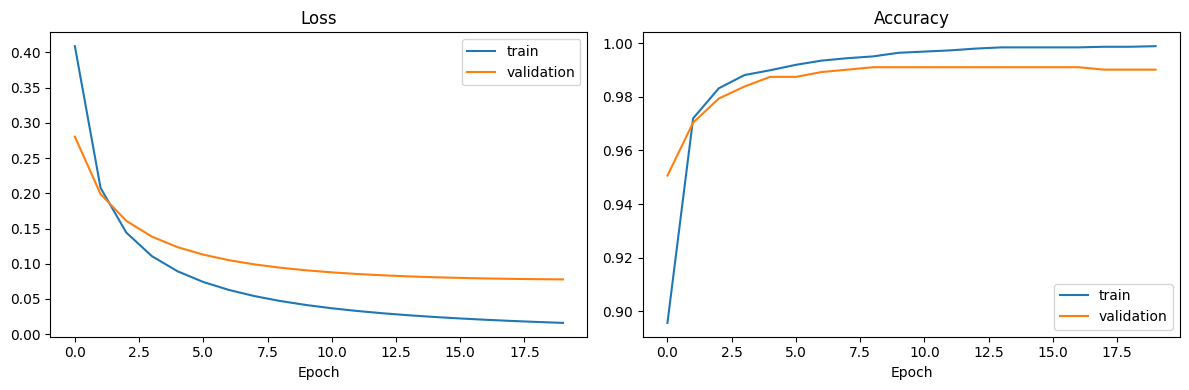

loss: 0.0778
compile_metrics: 0.9901
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion matrix [rows=true, cols=pred]:
 [[978   0]
 [ 11 125]]


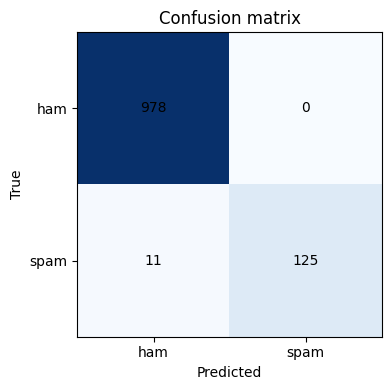

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="validation")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
 
ax2.plot(history.history["accuracy"], label="train")
ax2.plot(history.history["val_accuracy"], label="validation")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
 
plt.tight_layout()
plt.show()
 
results = model.evaluate(val_ds, verbose=0)
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")
 
# Build the confusion matrix by hand from predictions.
y_true = np.concatenate([y.numpy().ravel() for _, y in val_ds], axis=0)
y_prob = model.predict(val_ds).ravel()
y_pred = (y_prob >= 0.5).astype("int32")   # threshold probabilities into 0/1
 
# tf.math.confusion_matrix replaces sklearn's confusion_matrix.
cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=2).numpy()
print("Confusion matrix [rows=true, cols=pred]:\n", cm)
 
# Plot it with matplotlib (replaces ConfusionMatrixDisplay).
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["ham", "spam"])
ax.set_yticks([0, 1], labels=["ham", "spam"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


### 6 Own Exampel

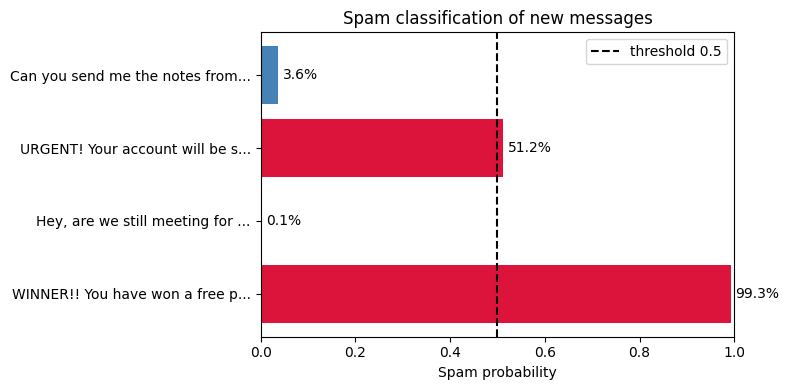

In [61]:
def classify(message: str) -> float:
    return float(model.predict(tf.constant([[message]]), verbose=0)[0, 0])

messages = [
    "WINNER!! You have won a free prize, call now to claim",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Your account will be suspended, verify now",
    "Can you send me the notes from class?",
]

probs = [classify(m) for m in messages]
colors = ["crimson" if p >= 0.5 else "steelblue" for p in probs]
short = [m[:30] + "..." if len(m) > 30 else m for m in messages]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(short, probs, color=colors)
ax.axvline(0.5, color="black", linestyle="--", label="threshold 0.5")
ax.set_xlim(0, 1)
ax.set_xlabel("Spam probability")
ax.set_title("Spam classification of new messages")
ax.legend()

for i, p in enumerate(probs):
    ax.text(p + 0.01, i, f"{p:.1%}", va="center")

plt.tight_layout()
plt.show()